Student: sba25345
Data Visualisation


************************************************************************************************************************

#                                      Analysis for retailer of the video games 
#                                             or the sales strategy in their upcoming Summer season.

************************************************************************************************************************

### Step 1 - DATA PREPARATION
Importing libraries as a standard inital preparation step.
I am also adding the style, loading the dataset and usinging encoder latin1 to ensure special characters in the dataset will be captured.

#### Rationale:
* Importing necessary libraries for data manipulation (pandas), 
* visualization (matplotlib, seaborn - for enchancing visuals), and setting up palette for consisten styling,
* Set a vibrant yet professional palette inspired by gaming retail (neon accents on dark base)
    * to align with the Summer season strategy audience. This creates Unity and Repetition across visuals.
      I also choosed the pallet which is inspired by gaming-retail industry.
* statistical analysis (scipy for correlation).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

custom_palette = ['#62C370', '#FFD166', '#EF476F', '#00f5a0', '#ff006e']
sns.set_palette(custom_palette)
sns.set_style("darkgrid", {"axes.facecolor": "#1f1f1f", "grid.color": "#333333"})
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

print("Setup complete with gaming-aligned styling.")

Setup complete with gaming-aligned styling.


### Loading Data & Initial Preparation, look at the dataset.

#### Rationale:

* Load the dataset. Perform targeted feature engineering for 'year' to fix 2010.0 / Int64 issues required for Question no. 4.
* Sales NaNs filled with 0 (missing = no sales). Per-question dropna used later to preserve data volume.
  Reason/Why: Isnull shows a lot of data with NaNs as high as 89.56% for critic_score.

In [13]:
#loading data
df = pd.read_csv('vgchartz-2024.csv', encoding='latin1')

In [14]:
df.shape

(64016, 14)

In [31]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,year
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013.0
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014.0
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002.0
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013.0
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015.0


In [32]:
print("\nLast 5 rows:")
df.tail()


Last 5 rows:


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,year
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,0.0,0.0,0.0,0.0,0.0,2016-08-11,2019-01-28,2016.0
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,0.0,0.0,0.0,0.0,0.0,2020-07-30,2020-05-09,2020.0
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,0.0,0.0,0.0,0.0,0.0,2020-07-30,2020-05-09,2020.0
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,0.0,0.0,0.0,0.0,0.0,2019-02-28,2019-02-24,2019.0
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,0.0,0.0,0.0,0.0,0.0,NaT,2023-09-29,NaN


In [17]:
df.describe(include=object) 

,img,title,console,genre,publisher,developer,release_date,last_update
count,64016,64016,64016,64016,64016,63999,56965,17879
unique,56177,39798,81,20,3383,8862,7922,1545
top,/games/boxart/default.jpg,Plants vs. Zombies,PC,Misc,Unknown,Unknown,1994-01-01,2018-01-06
freq,7810,17,12617,9304,8842,4435,515,165


In [18]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [20]:
df.duplicated().sum()

0

In [21]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [22]:
nan_percent = df.isna().mean() * 100
print("\nNaN percentages per column:")
print(nan_percent)


NaN percentages per column:
img              0.000000
title            0.000000
console          0.000000
genre            0.000000
publisher        0.000000
developer        0.026556
critic_score    89.568233
total_sales     70.441765
na_sales        80.259623
jp_sales        89.493252
pal_sales       79.967508
other_sales     76.368408
release_date    11.014434
last_update     72.071045
dtype: float64


In [23]:
#Feature engineering
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year.astype('float64') # Use of float64 to avoid Int64 issues in seaborn which I had encountered while working on this project.

In [24]:
df['year'] = df['year'].round(0).astype('float64')  # float64 avoids seaborn Int64 errors

In [34]:
print("\nYear added:")
print(df.columns.tolist())


Year added:
['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'year']


In [36]:
print("\n sales NaNs filled with 0") 
sales_cols = ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
df[sales_cols] = df[sales_cols].fillna(0)


 sales NaNs filled with 0


In [30]:
print(df['year'].value_counts(dropna=False).sort_index())

year
1971.0       1
1973.0       1
1975.0       1
1977.0      11
1978.0      45
1979.0       8
1980.0      35
1981.0      50
1982.0     214
1983.0     298
1984.0     102
1985.0     101
1986.0     159
1987.0     270
1988.0     294
1989.0     426
1990.0     657
1991.0     779
1992.0     933
1993.0    1034
1994.0    1163
1995.0    1153
1996.0    1228
1997.0    1040
1998.0    1096
1999.0    1272
2000.0    1552
2001.0    1478
2002.0    1726
2003.0    1723
2004.0    1606
2005.0    1810
2006.0    2096
2007.0    2525
2008.0    2936
2009.0    4360
2010.0    3586
2011.0    3386
2012.0    1584
2013.0    1740
2014.0    2896
2015.0    1680
2016.0    1352
2017.0    1558
2018.0    1538
2019.0    1290
2020.0    1452
2021.0     422
2022.0     168
2023.0     108
2024.0      22
NaN       7051
Name: count, dtype: int64


In [37]:
# Optional safety: fill extreme outliers 
df.loc[(df['year'] < 1980) | (df['year'] > 2025), 'year'] = pd.NA

In [41]:
print("Year column fixed, except.0 due to Float64 choice. Sample values:")
print(df['year'].value_counts(dropna=False).sort_index().head(10))
print(df['year'].value_counts(dropna=False).sort_index().tail(10))

Year column fixed, except.0 due to Float64 choice. Sample values:
year
1980.0     35
1981.0     50
1982.0    214
1983.0    298
1984.0    102
1985.0    101
1986.0    159
1987.0    270
1988.0    294
1989.0    426
Name: count, dtype: int64
year
2016.0    1352
2017.0    1558
2018.0    1538
2019.0    1290
2020.0    1452
2021.0     422
2022.0     168
2023.0     108
2024.0      22
NaN       7118
Name: count, dtype: int64


In [43]:
print("Shape:", df.shape)
print("\nNaN summary after cleaning:\n", df.isna().sum())
print("\nYear sample:", df['year'].dropna().unique()[:10])

Shape: (64016, 15)

NaN summary after cleaning:
 img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales         0
na_sales            0
jp_sales            0
pal_sales           0
other_sales         0
release_date     7051
last_update     46137
year             7118
dtype: int64

Year sample: [2013. 2014. 2002. 2015. 2011. 2010. 2018. 2012. 2009. 2017.]


************************************************************************************************************************

# PART 1

************************************************************************************************************************

# QUESTION 1:
                                    ## TOP 5 PUBLISHERS BY OTHER_SALES
                                                ## PIE CHART
                            ## (Type 1: Composition/Proportion of Market Share )


In [45]:
q1_df = df.dropna(subset=['publisher', 'other_sales']).copy()
top_publishers = (q1_df.groupby('publisher')['other_sales']
                  .sum()
                  .reset_index()
                  .sort_values('other_sales', ascending=False)
                  .head(5))

Top 5 Publishers by Other Sales:
                        publisher  other_sales
101                    Activision        77.59
852               Electronic Arts        75.14
813                     EA Sports        57.50
3043                      Ubisoft        50.29
2674  Sony Computer Entertainment        42.48


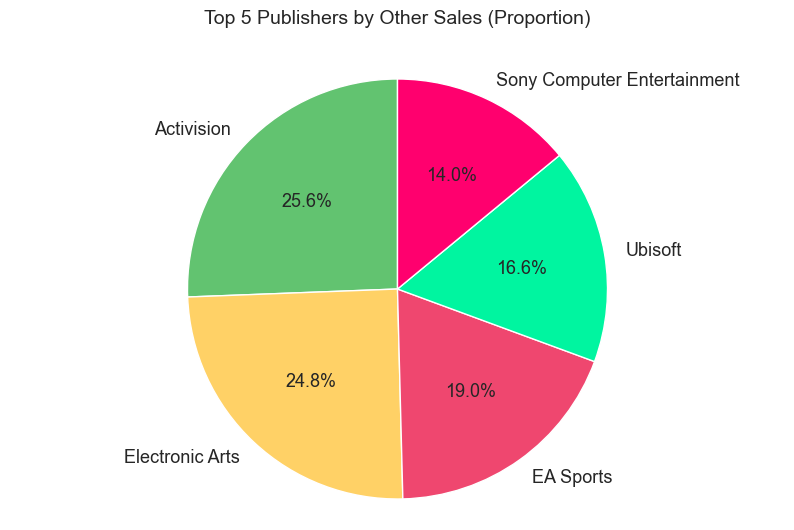

In [56]:
print("Top 5 Publishers by Other Sales:")
print(top_publishers)

plt.figure(figsize=(10, 6))
plt.pie(top_publishers['other_sales'], labels=top_publishers['publisher'],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
plt.title('Top 5 Publishers by Other Sales (Proportion)', fontsize=14, pad=25)
plt.axis('equal')
plt.show()
    

#### Rationale for Question 1:

* Data engineering: Groupby and sum for aggregation; head(5) for top selection. Filled NaNs with 0 earlier to include all data.
* Visualization choice: Pie chart to show proportions among top 5, effective for small categories (Chen et al., 2008).
* Design: Colors from palette; autopct for percentages; startangle for better label positioning; suggesting top 2 visually; font size 13 for readability; title centered.

Pie is fine for proportions, but for top 5, a bar chart shows absolute differences better (pies can mislead on small slices).
Additional Viz Rationale: Bar chart complements pie by showing raw magnitudes, easier to compare differences (Chen et al., 2008).

I added one more visual for this question in order to show absolute values in ascending order for quick reassurance of the report audience. 
Works well for colour or shape challenges, therefor it is more readable.

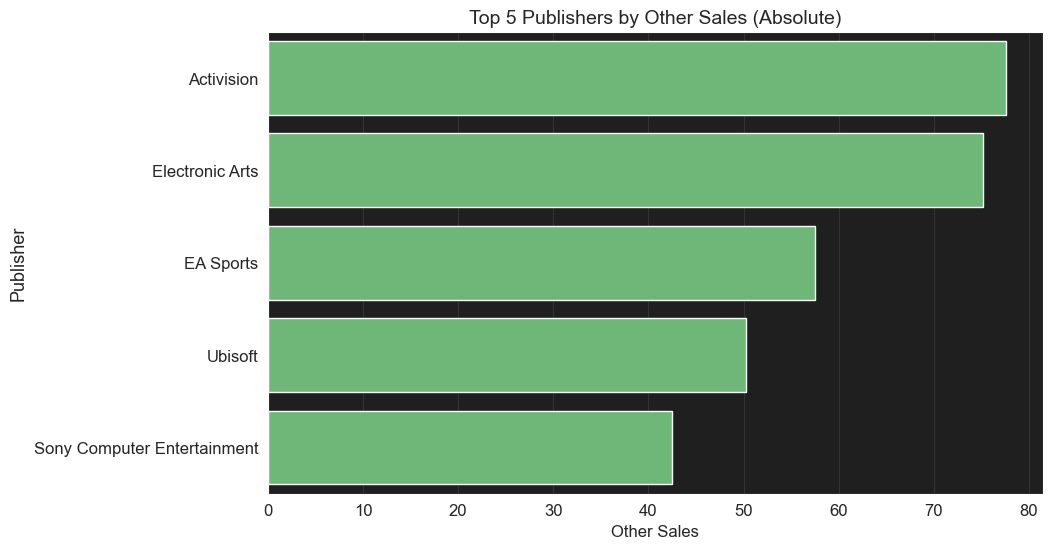

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_publishers, x='other_sales', y='publisher')
plt.title('Top 5 Publishers by Other Sales (Absolute)', fontsize=14)
plt.xlabel('Other Sales', fontsize=12)
plt.ylabel('Publisher', fontsize=13)
plt.show()

************************************************************************************************************************

# QUESTION 2:
                                    ## CORRELATION PAL vs NA SALES 2010-2020
                                             ## (SCATTER + MATRIX)
                                           ## (Type 2: Relationship)

         ## Sales of copies in millions for European & African sales (PAL) vs North American sales (NA)                                          